In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# show charts inside the notebook
%matplotlib inline 

# Load the raw data — use the first sheet
df = pd.read_excel('palmpay_transactions_jan2024.xlsx',
sheet_name='transactions_jan2024')

print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Loaded: 50 rows, 8 columns


,transaction_id,user_id,transaction_date,transaction_type,amount_ngn,status,channel,region
0,TXN-0001,USR-3615,2024-01-11,Transfer,29900,Failed,Web,Lagos
1,TXN-0002,USR-1106,2024-01-15,Deposit,91310,Success,Web,Ibadan
2,TXN-0003,USR-2679,2024-01-23,Transfer,48340,Pending,USSD,Lagos
3,TXN-0004,USR-2535,2024-01-09,Withdrawal,15660,Success,Web,Lagos
4,TXN-0005,USR-7873,2024-01-21,Airtime,21040,Success,USSD,NaN


In [2]:
print(f'Shape: {df.shape}') # (rows, columns)

# column names, types, non-null counts
df.info() 

# min, max, mean, std, quartiles for numeric columns
df.describe() 

Shape: (50, 8)
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    50 non-null     str           
 1   user_id           50 non-null     str           
 2   transaction_date  50 non-null     datetime64[us]
 3   transaction_type  50 non-null     str           
 4   amount_ngn        50 non-null     int64         
 5   status            50 non-null     str           
 6   channel           50 non-null     str           
 7   region            45 non-null     str           
dtypes: datetime64[us](1), int64(1), str(6)
memory usage: 3.3 KB


,transaction_date,amount_ngn
count,50,50.000000
mean,2023-08-23 15:50:24,122908.000000
min,2004-01-17 00:00:00,-439240.000000
25%,2024-01-08 06:00:00,4465.000000
50%,2024-01-15 12:00:00,25470.000000
75%,2024-01-23 00:00:00,350492.500000
max,2024-01-31 00:00:00,473150.000000
std,NaN,207144.491245


In [3]:
print('Missing values per column:')
print(df.isnull().sum())
print('\nUnique values per column:')
print(df.nunique())
print('\nStatus distinct values:', df['status'].unique())

# Find duplicate transaction IDs
dup_count = df.duplicated(subset=['transaction_id']).sum()

print(f'\nDuplicate transaction IDs: {dup_count}')
df[df.duplicated(subset=['transaction_id'], keep=False)]

Missing values per column:
transaction_id      0
user_id             0
transaction_date    0
transaction_type    0
amount_ngn          0
status              0
channel             0
region              5
dtype: int64

Unique values per column:
transaction_id      48
user_id             22
transaction_date    26
transaction_type     5
amount_ngn          50
status               7
channel              4
region               5
dtype: int64

Status distinct values: <StringArray>
['Failed', 'Success', 'Pending', 'success', 'SUCCESS', 'failed', 'PENDING']
Length: 7, dtype: str

Duplicate transaction IDs: 2


,transaction_id,user_id,transaction_date,transaction_type,amount_ngn,status,channel,region
2,TXN-0003,USR-2679,2024-01-23,Transfer,48340,Pending,USSD,Lagos
7,TXN-0003,USR-2424,2024-01-05,Airtime,441650,Success,Agent,Kano
14,TXN-0015,USR-9935,2024-01-02,Airtime,10610,Failed,USSD,Abuja
21,TXN-0015,USR-5552,2024-01-24,Transfer,261090,Success,App,Abuja


In [5]:
# Start with a full copy — never modify the original
df_clean = df.copy()

# FIX 1: Standardise status casing — Python IS case-sensitive unlike Excel
df_clean['status'] = df_clean['status'].str.strip().str.title()

# FIX 2: Replace negative amounts with 0
df_clean['amount_ngn'] = df_clean['amount_ngn'].clip(lower=0)

# FIX 3: Convert to datetime safely + correct year outliers
df_clean['transaction_date'] = pd.to_datetime(df_clean['transaction_date'], errors='coerce')

mask = df_clean['transaction_date'].dt.year != 2024

df_clean.loc[mask, 'transaction_date'] = df_clean.loc[mask, 'transaction_date'].apply(
    lambda x: x.replace(year=2024) if pd.notnull(x) else x
)

# FIX 4: Fill missing regions with 'Unknown'
df_clean['region'] = df_clean['region'].fillna('Unknown')

# FIX 5: Flag (don't delete) duplicate transaction IDs
df_clean['is_duplicate'] = df_clean.duplicated(
    subset=['transaction_id'], keep=False
)

# Verify all 5 fixes worked
print(f'Null regions: {df_clean["region"].isnull().sum()}')
print(f'Negative amounts: {(df_clean["amount_ngn"] < 0).sum()}')
print(f'Status values: {sorted(df_clean["status"].dropna().unique())}')

print(
    f'Date range: {df_clean["transaction_date"].min().date()} to '
    f'{df_clean["transaction_date"].max().date()}'
)

Null regions: 0
Negative amounts: 0
Status values: ['Failed', 'Pending', 'Success']
Date range: 2024-01-02 to 2024-01-31


         count  total_vol  avg_amount   pct
status                                     
Success     36    5402840   150078.89  72.0
Failed       9     504710    56078.89  18.0
Pending      5     927170   185434.00  10.0


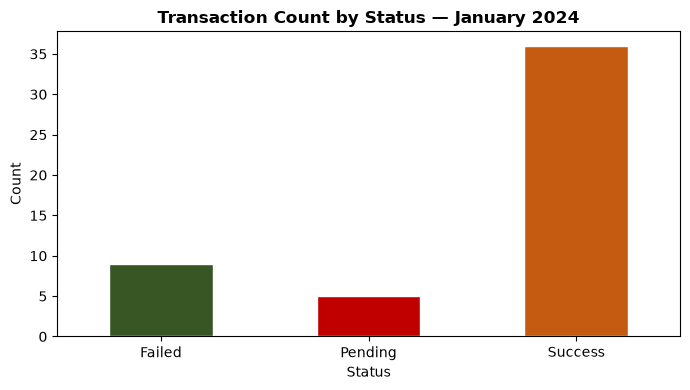

In [6]:
status_summary = df_clean.groupby('status').agg(
    count=('transaction_id', 'count'),
    total_vol=('amount_ngn', 'sum'),
    avg_amount=('amount_ngn', 'mean')
).round(2)

status_summary['pct'] = (
    status_summary['count'] / status_summary['count'].sum() * 100
).round(1)

print(
    status_summary.sort_values(
        'count',
        ascending=False
    )
)

status_summary['count'].plot(
    kind='bar',
    color=['#375623', '#C00000', '#C55A11'],
    figsize=(7, 4),
    edgecolor='white'
)

plt.title(
    'Transaction Count by Status — January 2024',
    fontweight='bold'
)

plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

               txn_count  total_vol  avg_amount
region                                         
Lagos                  9    2125170    236130.0
Kano                   8    1021240    127655.0
Unknown                5     995720    199144.0
Port Harcourt          5     510720    102144.0
Ibadan                 4     422620    105655.0
Abuja                  5     327370     65474.0


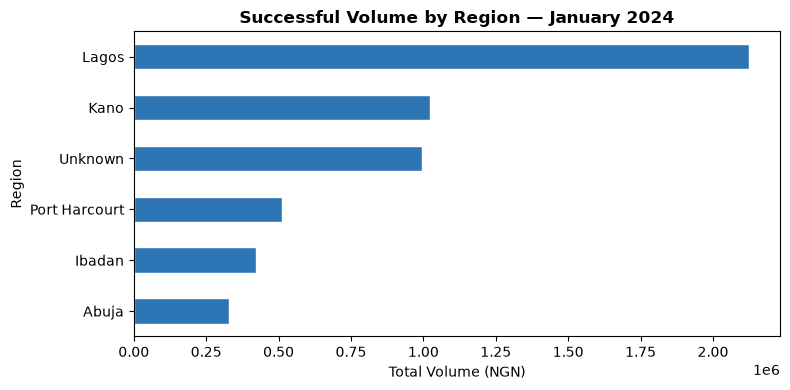

In [7]:
# Filter to successful transactions — Python equivalent of WHERE status = 'Success'
df_ok = df_clean[df_clean['status'] == 'Success']

region_vol = df_ok.groupby('region').agg(
    txn_count=('transaction_id', 'count'),
    total_vol=('amount_ngn', 'sum'),
    avg_amount=('amount_ngn', 'mean')
).round(2).sort_values(
    'total_vol',
    ascending=False
)

print(region_vol)

region_vol['total_vol'].sort_values().plot(
    kind='barh',
    figsize=(8, 4),
    color='#2E75B6',
    edgecolor='white'
)

plt.title(
    'Successful Volume by Region — January 2024',
    fontweight='bold'
)

plt.xlabel('Total Volume (NGN)')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

Peak day: 2024-01-05 with 4 transactions


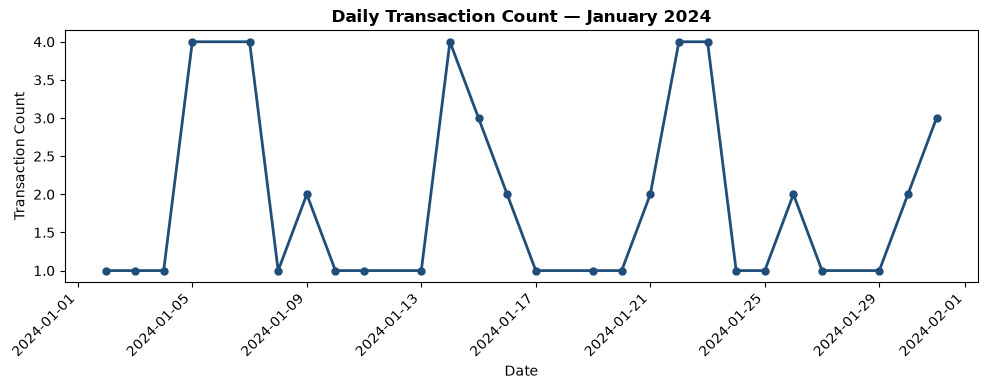

In [8]:
df_clean['transaction_date'] = pd.to_datetime(
    df_clean['transaction_date']
)

daily = df_clean.groupby('transaction_date').agg(
    txn_count=('transaction_id', 'count'),
    daily_volume=('amount_ngn', 'sum')
)

peak = daily['txn_count'].idxmax()

print(
    f'Peak day: {peak.date()} '
    f'with {daily["txn_count"].max()} transactions'
)

daily['txn_count'].plot(
    figsize=(10, 4),
    color='#1F4E79',
    marker='o',
    linewidth=2,
    markersize=5
)

plt.title(
    'Daily Transaction Count — January 2024',
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('Transaction Count')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

         total  success  failed  success_rate  failure_rate
channel                                                    
Web         16       10       5          62.5          31.2
App         10        7       2          70.0          20.0
USSD        16       13       2          81.2          12.5
Agent        8        6       0          75.0           0.0

Flagged channels: ['Web', 'App']


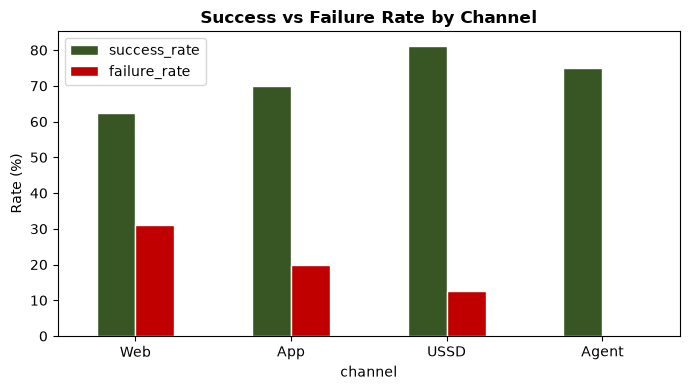

In [9]:
ch = df_clean.groupby('channel').agg(
    total=('transaction_id', 'count'),
    success=('status', lambda x: (x == 'Success').sum()),
    failed=('status', lambda x: (x == 'Failed').sum())
).assign(
    success_rate=lambda x: (
        x['success'] / x['total'] * 100
    ).round(1),
    failure_rate=lambda x: (
        x['failed'] / x['total'] * 100
    ).round(1)
).sort_values(
    'failure_rate',
    ascending=False
)

print(ch)

# Channels above 15% — Python equivalent of SQL HAVING
print(
    '\nFlagged channels:',
    list(ch[ch['failure_rate'] > 15].index)
)

ch[['success_rate', 'failure_rate']].plot(
    kind='bar',
    figsize=(7, 4),
    color=['#375623', '#C00000'],
    edgecolor='white'
)

plt.title(
    'Success vs Failure Rate by Channel',
    fontweight='bold'
)

plt.ylabel('Rate (%)')
plt.xticks(rotation=0)
plt.legend()

plt.tight_layout()
plt.show()

Mean: NGN   142,390.00
Median: NGN    30,635.00
Std deviation: NGN   186,181.36
Q1 (25th pct): NGN     4,600.00
Q3 (75th pct): NGN   365,410.00
Outlier fence: NGN   906,625.00

Outlier transactions: 0
Empty DataFrame
Columns: [transaction_id, amount_ngn, status, transaction_type]
Index: []


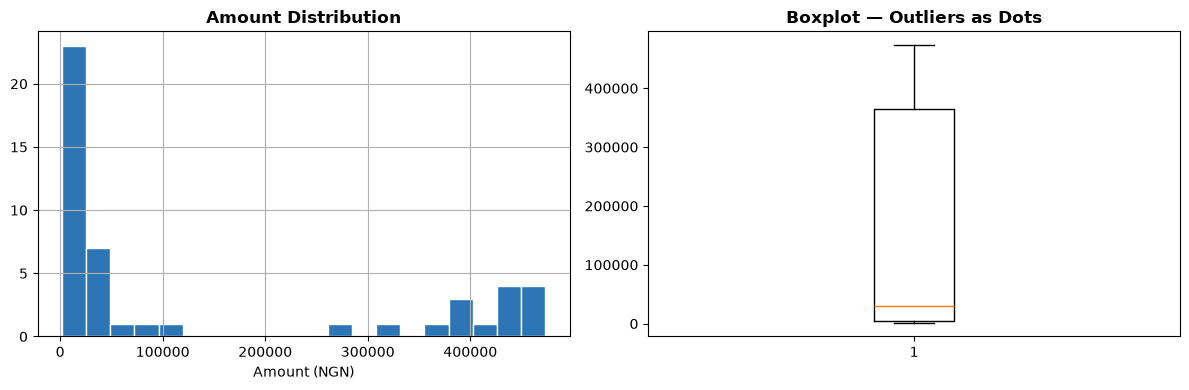

In [12]:
amounts = df_clean[df_clean['amount_ngn'] > 0]['amount_ngn']

q1 = amounts.quantile(0.25)
q3 = amounts.quantile(0.75)

iqr = q3 - q1

# Standard outlier threshold
fence = q3 + 1.5 * iqr

print(f'Mean: NGN {amounts.mean():>12,.2f}')
print(f'Median: NGN {amounts.median():>12,.2f}')
print(f'Std deviation: NGN {amounts.std():>12,.2f}')
print(f'Q1 (25th pct): NGN {q1:>12,.2f}')
print(f'Q3 (75th pct): NGN {q3:>12,.2f}')
print(f'Outlier fence: NGN {fence:>12,.2f}')

outliers = df_clean[df_clean['amount_ngn'] > fence]

print(f'\nOutlier transactions: {len(outliers)}')

print(
    outliers[
        [
            'transaction_id',
            'amount_ngn',
            'status',
            'transaction_type'
        ]
    ]
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

amounts.hist(
    bins=20,
    ax=axes[0],
    color='#2E75B6',
    edgecolor='white'
)

axes[0].set_title(
    'Amount Distribution',
    fontweight='bold'
)

axes[0].set_xlabel('Amount (NGN)')

axes[1].boxplot(amounts)

axes[1].set_title(
    'Boxplot — Outliers as Dots',
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [13]:
df_clean.to_csv(
    'palmpay_jan2024_clean.csv',
    index=False
)

print("Export complete: palmpay_jan2024_clean.csv")

Export complete: palmpay_jan2024_clean.csv
